# Parameters

In [ ]:
# ==========================================
# CONFIGURATION CENTRALE DES PARAMÈTRES
# ==========================================
cfg = {
    'I': 1,           # Carbon Input
    'd': 0.00067,     # Decomposition rate
    'm': 0.02,        # Mortality rate
    'e': 0.3,         # CUE
    'gamma': 1.0,     # Recycling
    'X0': 100.0,      # Initial SOC
    'Y0': 1.0,        # Initial Biomass
    'dt': 0.01,       # Time step
    'n_steps': 500000,# Number of time steps
    'noise_std': 1e-1 # Noise
}

In [5]:
# ==========================================
# PARAMÈTRES D'ELISA
# ==========================================
cfg = {
    'I': 1,           # Carbon Input
    'd': 0.01,     # Decomposition rate
    'm': 1.0,        # Mortality rate
    'e': 0.35,         # CUE
    'gamma': 1.0,     # Recycling
    'X0': 100.0,      # Initial SOC
    'Y0': 5.0,        # Initial Biomass
    'dt': 0.01,       # Time step
    'n_steps': 500000, # Steps
    'noise_std': 1e-6 # Noise
}

# Model

In [2]:
# MODEL EQUATIONS

import sympy as sp

# --- 1. Symbol definition ---
X, Y = sp.symbols('X Y')
I, d, m, e = sp.symbols('I d m e')
alpha, beta, gamma = sp.symbols('alpha beta gamma')

# --- 2. Generalized model definition ---
# dX/dt = I - d*X*Y^alpha + gamma*m*Y^beta 
f_gen = I - d * X * Y**alpha + gamma * m * Y**beta
# dY/dt = e*d*X*Y^alpha - m*Y^beta [cite: 88, 99]
g_gen = e * d * X * Y**alpha - m * Y**beta

print("GENERALIZED CAUSAL SYSTEM STRUCTURE")
print("-" * 40)
display(sp.Eq(sp.Symbol('dX/dt'), f_gen))
display(sp.Eq(sp.Symbol('dY/dt'), g_gen))
print("-" * 40)

# --- 3. Printing specific model configurations ---
configs = [
    {"name": "LINEAR KINETICS", "alpha": 0, "beta": 1},
    {"name": "MULTIPLICATIVE KINETICS", "alpha": 1, "beta": 1},
    {"name": "DENSITY DEPENDENT MORTALITY", "alpha": 1, "beta": 2}
]

for conf in configs:
    print(f"\nSYSTEM EQUATIONS: {conf['name']}")
    print(f"(Parameters: alpha={conf['alpha']}, beta={conf['beta']})")
    
    # Substituting alpha and beta values into the generalized equations
    f_spec = f_gen.subs({alpha: conf['alpha'], beta: conf['beta']})
    g_spec = g_gen.subs({alpha: conf['alpha'], beta: conf['beta']})
    
    display(sp.Eq(sp.Symbol('dX/dt'), f_spec))
    display(sp.Eq(sp.Symbol('dY/dt'), g_spec))

GENERALIZED CAUSAL SYSTEM STRUCTURE
----------------------------------------


Eq(dX/dt, I - X*Y**alpha*d + Y**beta*gamma*m)

Eq(dY/dt, X*Y**alpha*d*e - Y**beta*m)

----------------------------------------

SYSTEM EQUATIONS: LINEAR KINETICS
(Parameters: alpha=0, beta=1)


Eq(dX/dt, I - X*d + Y*gamma*m)

...

Eq(dX/dt, I - X*Y*d + Y*gamma*m)

Eq(dY/dt, X*Y*d*e - Y*m)


SYSTEM EQUATIONS: DENSITY DEPENDENT MORTALITY
(Parameters: alpha=1, beta=2)


Eq(dX/dt, I - X*Y*d + Y**2*gamma*m)

Eq(dY/dt, X*Y*d*e - Y**2*m)

# Pick your model

In [3]:
# Choose your kinetics here (uncomment one)
# current_conf = {"name": "LINEAR KINETICS", "alpha": 0, "beta": 1}
current_conf = {"name": "MULTIPLICATIVE KINETICS", "alpha": 1, "beta": 1}
# current_conf = {"name": "DENSITY DEPENDENT MORTALITY", "alpha": 1, "beta": 2}

# Jacobian and gain analysis

In [ ]:
# --- 4. STEADY STATE & STRUCTURAL GAIN ANALYSIS ---

print(f"\n>>> ANALYZING: {current_conf['name']} (Steady State & Gain)")
print("-" * 60)

# A. Substitution of alpha and beta
f_spec = f_gen.subs({alpha: current_conf['alpha'], beta: current_conf['beta']})
g_spec = g_gen.subs({alpha: current_conf['alpha'], beta: current_conf['beta']})

# B. Solving for Steady States
ss_solutions = sp.solve([f_spec, g_spec], (X, Y))

# --- AJOUT : Normalisation pour gérer les formats dict et list ---
if isinstance(ss_solutions, dict):
    ss_list = [(ss_solutions[X], ss_solutions[Y])]
elif isinstance(ss_solutions, list) and len(ss_solutions) > 0 and isinstance(ss_solutions[0], dict):
    ss_list = [(s[X], s[Y]) for s in ss_solutions]
else:
    ss_list = ss_solutions

num_solutions = len(ss_list)
print(f"[WARNING] {num_solutions} steady state(s) found.") if num_solutions > 1 else print("Unique steady state found.")

# --- C. Numerical Evaluation & Selection ---
params_values = {I: cfg['I'], d: cfg['d'], m: cfg['m'], e: cfg['e'], gamma: cfg['gamma']}
valid_solutions = []

for i, sol in enumerate(ss_list): # <--- Changer ss_solutions par ss_list
    x_val = float(sp.re(sol[0].subs(params_values)))
    y_val = float(sp.re(sol[1].subs(params_values)))
    
    is_positive = (x_val > 0 and y_val > 0)
    if is_positive:
        valid_solutions.append(sol)
    
    print(f"Solution #{i+1}: X_ss = {x_val:.4f}, Y_ss = {y_val:.4f} | Positive: {is_positive}")

# --- D. Selection Logic for Gain Calculation ---
if len(valid_solutions) == 0:
    print("\n[ERROR] No positive steady state found. Gain calculation aborted.")
elif len(valid_solutions) > 1:
    print("\n[ERROR] Several steady states are positive. Automatic gain calculation aborted.")
else:
    # We have exactly one positive solution
    X_val_ss, Y_val_ss = valid_solutions[0]
    print(f"\nProceeding with the unique positive steady state.")

    # --- Définition de la Jacobienne pour le modèle courant ---
    F = sp.Matrix([f_spec, g_spec])
    vars_mat = sp.Matrix([X, Y])
    J_sym = F.jacobian(vars_mat)
    
    # Évaluation au Steady State sélectionné
    J_at_ss = J_sym.subs({X: X_val_ss, Y: Y_val_ss})
    
    print("\n2. Jacobian Matrix at Steady State (s_ij):")
    display(J_at_ss)

    # --- E. Structural Gain Calculation ---
    j11, j12 = J_at_ss[0,0], J_at_ss[0,1]
    j21, j22 = J_at_ss[1,0], J_at_ss[1,1]
    
    denominator = j11 * j22
    if denominator == 0:
        print("\n[ERROR] Gain calculation aborted because denominator is zero.")
    else:
        symbolic_gain = sp.simplify((j12 * j21) / denominator)
        
        print("\n3. Symbolic Gain Expression:")
        # display() renders the expression with Greek letters and proper math formatting
        display(sp.Eq(sp.Symbol('G'), symbolic_gain))

        # --- F. Final Numerical Gain ---
        params_values = {I: cfg['I'], d: cfg['d'], m: cfg['m'], e: cfg['e'], gamma: cfg['gamma']}
        numerical_gain_expr = symbolic_gain.subs(params_values)
        final_gain = float(sp.re(numerical_gain_expr))
        
        print(f"\n4. Numerical Gain at Steady State: {final_gain:.4f}")

# Generating time series

>>> GENERATING TIME SERIES: MULTIPLICATIVE KINETICS


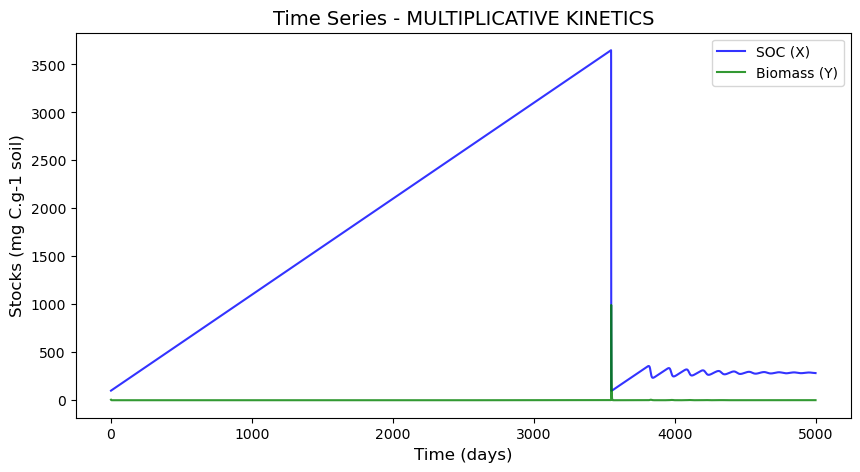

Simulation terminée. Stock SOC final : 282.92
Stock Biomasse final : 0.57


In [6]:
# --- SIMULATIONS GÉNÉRALISÉES ---

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print(f">>> GENERATING TIME SERIES: {current_conf['name']}")

# --- 1. Préparation des vecteurs ---
time = np.arange(cfg['n_steps']) * cfg['dt']
X = np.zeros(cfg['n_steps'])
Y = np.zeros(cfg['n_steps'])
X[0] = cfg['X0']
Y[0] = cfg['Y0']

# Extraction des exposants de cinétique
a = current_conf['alpha']
b = current_conf['beta']

# --- 2. Résolution numérique (Méthode d'Euler) ---
for t in range(1, cfg['n_steps']):
    x_prev = X[t-1]
    y_prev = Y[t-1]
    
    # Sécurité pour éviter les puissances sur valeurs négatives dues au bruit
    y_safe = max(y_prev, 1e-10)
    
    # Calcul des flux selon la forme générale :
    # Flux Décomposition = d * X * Y^alpha
    flux_decomp = cfg['d'] * x_prev * (y_safe**a)
    
    # Flux Mortalité = m * Y^beta
    flux_mortality = cfg['m'] * (y_safe**b)
    
    # Équations différentielles
    # dX/dt = I - flux_decomp + gamma * flux_mortality
    dX_val = (cfg['I'] - flux_decomp + cfg['gamma'] * flux_mortality) * cfg['dt']
    
    # dY/dt = e * flux_decomp - flux_mortality
    dY_val = (cfg['e'] * flux_decomp - flux_mortality) * cfg['dt']
    
    # Mise à jour avec ajout du bruit blanc
    X[t] = x_prev + dX_val + np.random.normal(0, cfg['noise_std'])
    Y[t] = y_prev + dY_val + np.random.normal(0, cfg['noise_std'])

# --- 3. Création du DataFrame et Export ---
df = pd.DataFrame({'Time': time, 'SOC': X, 'Biomass': Y})
df.to_csv('simulation_results.csv', index=False)

# --- 4. Visualisation ---
plt.figure(figsize=(10, 5))
plt.plot(time, X, label='SOC (X)', color='blue', alpha=0.8)
plt.plot(time, Y, label='Biomass (Y)', color='green', alpha=0.8)

plt.title(f"Time Series - {current_conf['name']}", fontsize=14)
plt.xlabel("Time (days)", fontsize=12)
plt.ylabel("Stocks (mg C.g-1 soil)", fontsize=12)
plt.legend()
plt.show()

print(f"Simulation terminée. Stock SOC final : {X[-1]:.2f}")
print(f"Stock Biomasse final : {Y[-1]:.2f}")

# Nonlinear Granger causality (Marinazzo 2008) 

In [ ]:
# ==================================================================================
# GRANGER CAUSALITY (MARINAZZO ET AL. 2008) - DEGREE-AWARE STEADY STATE ANALYSIS
# ==================================================================================

import numpy as np
from scipy import stats

# --- RÉGLAGES DE LA STRATÉGIE ---
M_LISTE_CV = [1, 2, 3, 4, 5]   
P_LISTE_EXPLORATION = [1, 2, 3, 4]  

# OPTIMISATION 1 : Sélection des 10% finaux (Steady State)
steady_state_start = int(cfg['n_steps'] * 0.9)
X_full_ss = X[steady_state_start:]
Y_full_ss = Y[steady_state_start:]

# OPTIMISATION 2 : Sous-échantillonnage (N=3000)
N_MAX_GRANGER = 3000
X_ss = X_full_ss[-N_MAX_GRANGER:]
Y_ss = Y_full_ss[-N_MAX_GRANGER:]

# Préparation des séries temporelles
target_x = np.diff(X_ss) 
target_y = np.diff(Y_ss)
X_in = X_ss[:-1]
Y_in = Y_ss[:-1]

def marinazzo_2008_steady_state(X_in, Y_in, t_X, t_Y, m_list, p_list, alpha=0.05):
    
    def create_lagged_matrix(series, m):
        return np.column_stack([series[m-1-i : len(series)-i] for i in range(m)])

    # --- ÉTAPE 1 : SÉLECTION DE M (Lag optimal) ---
    print(f"--- STEP 1: OPTIMAL LAG SELECTION (m) ---")
    mse_total = []
    se_total = []
    for m in m_list:
        errors_m = []
        for series, evol in [(X_in, t_X), (Y_in, t_Y)]:
            X_p = create_lagged_matrix(series, m)
            t_adj = evol[m-1:] 
            split = int(len(t_adj) * 0.8)
            tr_p, val_p = X_p[:split], X_p[split:]
            tr_t, val_t = t_adj[:split], t_adj[split:]
            mu, std = np.mean(tr_p, axis=0), np.std(tr_p, axis=0) + 1e-10
            tr_n, val_n = (tr_p - mu)/std, (val_p - mu)/std
            inv_k = np.linalg.pinv(np.dot(tr_n.T, tr_n) + np.eye(m) * 1e-6)
            beta = inv_k @ tr_n.T @ (tr_t - np.mean(tr_t))
            pred_val = (val_n @ beta) + np.mean(tr_t)
            errors_m.extend((val_t - pred_val)**2)
        mse_total.append(np.mean(errors_m))
        se_total.append(np.std(errors_m) / np.sqrt(len(errors_m)))
        print(f"  m={m} -> MSE: {mse_total[-1]:.4e}")

    best_m = m_list[np.argmin(mse_total)]
    print(f"  >> Optimal m selected: {best_m}\n")

    # --- ÉTAPE 2 : ÉVALUATION DE LA CAUSALITÉ (p) ---
    print(f"--- STEP 2: CAUSALITY ANALYSIS (p) ---")
    m = best_m
    t_X_adj, t_Y_adj = t_X[m-1:], t_Y[m-1:]
    X_p = create_lagged_matrix(X_in, m)
    Y_p = create_lagged_matrix(Y_in, m)
    N = len(t_X_adj)
    J = np.eye(N) - np.ones((N, N)) / N
    
    # Tracking for conclusion
    history = {"Y->X": [], "X->Y": []}

    for p in p_list:
        Z_raw = np.column_stack([X_p, Y_p])
        Z_n = (Z_raw - np.mean(Z_raw, axis=0)) / (np.std(Z_raw, axis=0) + 1e-10)
        K_glob = J @ ((1 + np.dot(Z_n, Z_n.T))**p) @ J
        ev, evec = np.linalg.eigh(K_glob)
        K_filt = (evec[:, ev >= ev.max()*1e-6] * ev[ev >= ev.max()*1e-6]) @ evec[:, ev >= ev.max()*1e-6].T
        
        for source_data, target_past, t_evol, lab in [(Z_n[:, m:], Z_n[:, :m], t_X_adj, "Y->X"), 
                                                      (Z_n[:, :m], Z_n[:, m:], t_Y_adj, "X->Y")]:
            y_c = t_evol - np.mean(t_evol)
            y_norm = y_c / (np.linalg.norm(y_c) + 1e-10)
            K_t = J @ ((1 + np.dot(target_past, target_past.T))**p) @ J
            ev_h, evec_h = np.linalg.eigh(K_t)
            P = evec_h[:, ev_h >= ev_h.max()*1e-6] @ evec_h[:, ev_h >= ev_h.max()*1e-6].T
            eps = 1 - np.dot(P @ y_norm, P @ y_norm) 
            K_tilde = K_filt - P@K_filt - K_filt@P + P@K_filt@P 
            ev_kt, evec_kt = np.linalg.eigh(K_tilde)
            keep_kt = ev_kt >= (ev_kt.max() * 1e-6 if ev_kt.max() > 0 else 1e-6)
            m_sig = np.sum(keep_kt)
            bonf = alpha / m_sig if m_sig > 0 else alpha 
            r_sq = [stats.pearsonr(evec_kt[:, i], y_norm)[0]**2 for i in range(len(ev_kt)) 
                    if keep_kt[i] and stats.pearsonr(evec_kt[:, i], y_norm)[1] < bonf]
            
            df = np.sum(r_sq) / eps if eps > 1e-12 else 0.0 
            history[lab].append(df)
            print(f"  p={p} | Direction {lab} | ΔF = {df:.6f}")

    # --- DEGREE-AWARE CONCLUSION ---
    print("\n" + "="*50)
    for lab in ["Y->X", "X->Y"]:
        scores = history[lab]
        if not scores or max(scores) == 0:
            print(f"DIRECTION {lab}: No significant causality detected.")
            continue
            
        best_p_idx = np.argmax(scores)
        best_p = p_list[best_p_idx]
        
        if best_p == 1:
            print(f"DIRECTION {lab}: Interaction is predominantly LINEAR.")
        else:
            print(f"DIRECTION {lab}: Interaction is predominantly POLYNOMIAL (Degree {best_p}).")
        
        # Check for overfitting (drop at p=4)
        if best_p_idx < len(scores) - 1:
            if scores[-1] < scores[best_p_idx] * 0.9:
                print(f"  >> Note: ΔF dropped at higher p, likely avoiding over-fitting.")
    print("="*50)

# Lancement de l'analyse
marinazzo_2008_steady_state(X_in, Y_in, target_x, target_y, M_LISTE_CV, P_LISTE_EXPLORATION)

# MLP (Tesch 2023)

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler
from scipy.stats import norm

# --- DATA PREPARATION ---
# --- Keep only the steady-state period (last 10% of data) ---
# This drastically reduces computation time and aligns with Jacobian analysis
steady_state_start = int(cfg['n_steps'] * 0.9)
X_ss = X[steady_state_start:]
Y_ss = Y[steady_state_start:]

# We use dX and dY as targets to approximate the differential equations
dX_target = np.diff(X_ss) 
dY_target = np.diff(Y_ss)
inputs_raw = np.column_stack([X_ss[:-1], Y_ss[:-1]])
targets_raw = np.column_stack([dX_target, dY_target])

class CausalMLP(nn.Module):
    def __init__(self):
        super(CausalMLP, self).__init__()
        # Tanh activation is crucial for smooth derivatives (C-infinity)
        self.net = nn.Sequential(
            nn.Linear(2, 64), nn.Tanh(), 
            nn.Linear(64, 64), nn.Tanh(),
            nn.Linear(64, 2)
        )
    def forward(self, x): return self.net(x)

def run_tesch_causal_engine(in_data, out_data, n_iterations=10, shuffle_col=None):
    qs_list = []
    gains_list = []
    
    for s in range(n_iterations):
        curr_in = in_data.copy()
        if shuffle_col is not None:
            np.random.seed(s)
            np.random.shuffle(curr_in[:, shuffle_col])

        sc_in, sc_out = StandardScaler(), StandardScaler()
        in_s = torch.tensor(sc_in.fit_transform(curr_in), dtype=torch.float32, requires_grad=True)
        out_s = torch.tensor(sc_out.fit_transform(out_data), dtype=torch.float32)

        model = CausalMLP()
        optimizer = optim.Adam(model.parameters(), lr=5e-4) # Slightly lower LR for stability
        criterion = nn.MSELoss()
        
        # OPTIMIZATION 2: Increased epochs to 2000 for deep convergence
        model.train()
        for epoch in range(2000):
            optimizer.zero_grad()
            output = model(in_s)
            loss = criterion(output, out_s)
            loss.backward()
            optimizer.step()

        model.eval()
        q_samples = []
        for i in range(len(in_s)):
            sample = in_s[i:i+1]
            pred = model(sample)
            # Computing partial derivatives (Jacobian elements)
            grad_dX = torch.autograd.grad(pred[0, 0], sample, retain_graph=True)[0]
            grad_dY = torch.autograd.grad(pred[0, 1], sample)[0]
            q_samples.append([grad_dX[0, 0].item(), grad_dX[0, 1].item(), 
                              grad_dY[0, 0].item(), grad_dY[0, 1].item()])
        
        s_matrix = np.mean(q_samples, axis=0) 
        dt = cfg['dt']
        
        # Conversion back to physical units
        q = [
            (s_matrix[0] * (sc_out.scale_[0] / sc_in.scale_[0])) / dt, # q11
            (s_matrix[1] * (sc_out.scale_[0] / sc_in.scale_[1])) / dt, # q12
            (s_matrix[2] * (sc_out.scale_[1] / sc_in.scale_[0])) / dt, # q21
            (s_matrix[3] * (sc_out.scale_[1] / sc_in.scale_[1])) / dt  # q22
        ]
        
        # OPTIMIZATION 3: Keep signs for feedback loop identification
        denom = (q[0] * q[3]) + 1e-10
        gain = (q[1] * q[2]) / denom
        
        qs_list.append(q)
        gains_list.append(gain)
        
    return np.array(qs_list), np.array(gains_list)

# --- EXECUTION & VALIDATION ---
print("\n[STEP 1] Running Uncertainty Ensemble (Hachurage)...")
qs_h, gains_h = run_tesch_causal_engine(inputs_raw, targets_raw, n_iterations=10)
q_means, q_stds = np.mean(qs_h, axis=0), np.std(qs_h, axis=0)

print("[STEP 2] Running Statistical Significance Tests...")
confidences = [0, 0, 0, 0]
for col in [0, 1]:
    qs_shuffled, _ = run_tesch_causal_engine(inputs_raw, targets_raw, n_iterations=5, shuffle_col=col)
    target_indices = [0, 2] if col == 0 else [1, 3]
    for idx in target_indices:
        null_samples = qs_shuffled[:, idx]
        mu, sigma = np.mean(null_samples), np.std(null_samples) + 1e-10
        p_val = 2 * (1 - norm.cdf(abs(q_means[idx] - mu) / sigma))
        confidences[idx] = max(0, (1 - p_val) * 100)

# --- FINAL REPORT ---
labels = ["SOC->dSOC (q11)", "Bio->dSOC (q12)", "SOC->dBio (q21)", "Bio->dBio (q22)"]
print(f"\nCAUSAL VALIDATION REPORT (TESCH 2023) - {current_conf['name']}")
print("-" * 85)
for i in range(4):
    status = "SIGNIFICANT" if confidences[i] > 95 else "POTENTIAL NOISE"
    print(f"{labels[i]:18} : {q_means[i]:10.6f} (± {q_stds[i]:.2e}) | Confidence: {confidences[i]:6.2f}% ({status})")

print("-" * 85)
mid = len(inputs_raw) // 2
_, g_v1_list = run_tesch_causal_engine(inputs_raw[:mid], targets_raw[:mid], n_iterations=3)
_, g_v2_list = run_tesch_causal_engine(inputs_raw[mid:], targets_raw[mid:], n_iterations=3)
g_v1, g_v2 = np.mean(g_v1_list), np.mean(g_v2_list)

print(f"TEMPORAL STABILITY ANALYSIS")
print(f"Mean Gain (Overall): {np.mean(gains_h):.4f}")
print(f"Gain Start (v1) : {g_v1:.4f} | Gain End (v2) : {g_v2:.4f}")

if abs(g_v1 - g_v2) / (abs(g_v1) + 1e-10) < 0.5:
    print(">>> RESULT: Model is TEMPORALLY STABLE.")
else:
    print(">>> RESULT: Model is TEMPORALLY UNSTABLE (Potential regime shift).")

In [ ]:
# --- CALCUL DES q_ij VIA 2 MODÈLES SÉPARÉS avec validations (Tesch 2023) ---

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler
from scipy.stats import norm

# --- 1. PRÉPARATION DES DONNÉES ---
# L'utilisation de dérivées temporelles discrètes (diff) permet d'étudier la dynamique 
# du système plutôt que de simples corrélations statiques entre variables.
dX = np.diff(X) 
dY = np.diff(Y)
inputs_raw = np.column_stack([X[:-1], Y[:-1]])
targets_raw = np.column_stack([dX, dY])

# --- 2. MODÈLE TORCH (EXPERT UNIQUE) ---
class CausalExpert(nn.Module):
    def __init__(self):
        super(CausalExpert, self).__init__()
        # Recommendation de Tesch : Utiliser Tanh car sa dérivabilité continue (C-infinity) 
        # est essentielle pour garantir la stabilité et la validité des gradients.
        self.net = nn.Sequential(
            nn.Linear(2, 50), nn.Tanh(), 
            nn.Linear(50, 50), nn.Tanh(),
            nn.Linear(50, 1) # Un expert dédié par variable cible
        )
    def forward(self, x): return self.net(x)

def run_tesch_dual_experts(in_data, out_data, n_iterations=10, shuffle_col=None):
    qs_list = []
    gains_list = []
    
    for s in range(n_iterations):
        curr_in = in_data.copy()
        # Recommendation : La permutation de l'entrée (shuffle) brise les liens causaux 
        # pour créer une distribution nulle permettant de tester la significativité.
        if shuffle_col is not None:
            np.random.seed(s)
            np.random.shuffle(curr_in[:, shuffle_col])

        sc_in, sc_out = StandardScaler(), StandardScaler()
        in_s = torch.tensor(sc_in.fit_transform(curr_in), dtype=torch.float32, requires_grad=True)
        out_s = torch.tensor(sc_out.fit_transform(out_data), dtype=torch.float32)

        # Recommendation : Initialiser les poids aléatoirement (hachurage) pour s'assurer 
        # que les résultats ne sont pas des artefacts liés à une convergence spécifique.
        model_X = CausalExpert()
        model_Y = CausalExpert()
        opt_X = optim.Adam(model_X.parameters(), lr=1e-3)
        opt_Y = optim.Adam(model_Y.parameters(), lr=1e-3)
        criterion = nn.MSELoss() # Le MSE est minimisé par l'espérance conditionnelle.
        
        model_X.train(); model_Y.train()
        for epoch in range(500):
            opt_X.zero_grad(); opt_Y.zero_grad()
            loss_X = criterion(model_X(in_s), out_s[:, 0].unsqueeze(1))
            loss_Y = criterion(model_Y(in_s), out_s[:, 1].unsqueeze(1))
            loss_X.backward(); loss_Y.backward()
            opt_X.step(); opt_Y.step()

        model_X.eval(); model_Y.eval()
        
        # --- CALCUL ÉCHANTILLON PAR ÉCHANTILLON ---
        # Recommendation : Calculer la dérivée partielle pour chaque échantillon individuel 
        # puis moyenner pour capturer la réponse causale sur toute la distribution.
        q_samples = []
        for i in range(len(in_s)):
            sample = in_s[i:i+1]
            pred_X = model_X(sample)
            grad_dX = torch.autograd.grad(pred_X, sample, retain_graph=True)[0]
            pred_Y = model_Y(sample)
            grad_dY = torch.autograd.grad(pred_Y, sample)[0]
            
            q_samples.append([grad_dX[0, 0].item(), grad_dX[0, 1].item(), 
                              grad_dY[0, 0].item(), grad_dY[0, 1].item()])
        
        s_matrix = np.mean(q_samples, axis=0) 
        dt = cfg['dt']
        
        # Recommendation : Utiliser le ratio des écarts-types pour convertir les sensibilités 
        # apprises en coefficients physiques réels (q_ij).
        q = [
            (s_matrix[0] * (sc_out.scale_[0] / sc_in.scale_[0])) / dt, # q11 (SOC->dSOC)
            (s_matrix[1] * (sc_out.scale_[0] / sc_in.scale_[1])) / dt, # q12 (Bio->dSOC)
            (s_matrix[2] * (sc_out.scale_[1] / sc_in.scale_[0])) / dt, # q21 (SOC->dBio)
            (s_matrix[3] * (sc_out.scale_[1] / sc_in.scale_[1])) / dt  # q22 (Bio->dBio)
        ]
        
        denom = (abs(q[0]) * abs(q[3])) + 1e-10
        gain = (abs(q[1]) * abs(q[2])) / denom
        qs_list.append(q)
        gains_list.append(gain)
        
    return np.array(qs_list), np.array(gains_list)

# --- 3. EXÉCUTION DES TESTS DE ROBUSTESSE ---
print("Exécution des tests (Hachurage, Permutations, Variantes)...")
qs_h, gains_h = run_tesch_dual_experts(inputs_raw, targets_raw, n_iterations=10)
q_means, q_stds = np.mean(qs_h, axis=0), np.std(qs_h, axis=0)

# --- CORRECTION DE LA LOGIQUE DE SIGNIFICATIVITÉ ---
confiances = [0, 0, 0, 0]
for col, name in [(0, "SOC"), (1, "Bio")]:
    # Permutation d'une entrée pour briser ses effets sur les sorties
    qs_shuffled, _ = run_tesch_dual_experts(inputs_raw, targets_raw, n_iterations=10, shuffle_col=col)
    
    # Correction des indices : col 0 (SOC) impacte q11 (idx 0) et q21 (idx 2)
    # col 1 (Bio) impacte q12 (idx 1) et q22 (idx 3)
    target_indices = [0, 2] if col == 0 else [1, 3]
    
    for idx in target_indices:
        null_samples = qs_shuffled[:, idx]
        mu, sigma = np.mean(null_samples), np.std(null_samples) + 1e-10
        # Recommendation : Utiliser la distribution normale N(mu, sigma) pour calculer 
        # la p-value de l'effet observé.
        p_val = 2 * (1 - norm.cdf(abs(q_means[idx] - mu) / sigma))
        confiances[idx] = max(0, (1 - p_val) * 100)

# Recommendation : Split chronologique (v1 vs v2) pour tester la stabilité temporelle 
# et identifier d'éventuelles corrélations fallacieuses (spurious correlations).
mid = len(inputs_raw) // 2
_, gains_v1 = run_tesch_dual_experts(inputs_raw[:mid], targets_raw[:mid], n_iterations=5)
_, gains_v2 = run_tesch_dual_experts(inputs_raw[mid:], targets_raw[mid:], n_iterations=5)

# --- 4. AFFICHAGE ET INTERPRÉTATION ---
labels = ["SOC->dSOC (q11)", "Bio->dSOC (q12)", "SOC->dBio (q21)", "Bio->dBio (q22)"]
print(f"\nRAPPORT DE VALIDATION CAUSALE - 2 MODÈLES SÉPARÉS (TESCH 2023)")
print("-" * 75)
for i in range(4):
    interpret = "NON ALÉATOIRE" if confiances[i] > 95 else "BRUIT POTENTIEL"
    print(f"{labels[i]:18} : {q_means[i]:10.6f} (± {q_stds[i]:.2e}) | Confiance Stat. : {confiances[i]:6.2f}% ({interpret})")

print("-" * 75)
g_v1, g_v2 = np.mean(gains_v1), np.mean(gains_v2)
ratio_v = max(g_v1, g_v2) / (min(g_v1, g_v2) + 1e-10)

print(f"STABILITÉ TEMPORELLE (Variant Approach)")
print(f"Gain v1 : {g_v1:.4f} | Gain v2 : {g_v2:.4f}")

if ratio_v < 2.0:
    print(">>> RÉSULTAT : Le modèle est STABLE temporellement.")
else:
    print(">>> RÉSULTAT : Le modèle est INSTABLE temporellement.")
    print(f"    Raison : Non-stationnarité des données ou corrélations fallacieuses locales.")